# Getting started with OnionNet

OnionNet is a wrapper around graph-tool, targeted towards large multilayered networks. This tutorial will show you how to get started.

In [1]:
import sys
import os
import pandas as pd

import onionnet
print("onionnet package located at:", onionnet.__file__)
from onionnet import OnionNet
import onionnet.visualisation
import onionnet.exporter 


import graph_tool.all as gt
from graph_tool.all import graph_draw

onionnet package located at: /Users/agjanyunlu/Documents/Metabolomics/onionnet/onionnet/__init__.py


## Inspecting data

For this example we will use a network from Netzschleuder, which is loadable via graph-tool. 

The data originates from a 1934 survey of school children in different grades, which was one of the earliest known uses of networks in sociology. For each child, they chose up to two students that they would like to sit next to in class. 

The full dataset is from: https://github.com/grandjeanmartin/sociograms. 
Full citation can be found on Netzschleuder (https://networks.skewed.de/net/moreno_sociograms) and in the local markdown file (`/.data/example_moreno_sociograms/About.md`).

In [2]:
g1 = gt.collection.ns["moreno_sociograms/grade_1"]
# pos_sfdp1 = gt.sfdp_layout(g)
g1

<Graph object, directed, with 35 vertices and 67 edges, 2 internal vertex properties, 6 internal graph properties, at 0x16e627560>

In [3]:
g2 = gt.collection.ns["moreno_sociograms/grade_2"]
# pos_sfdp2 = gt.sfdp_layout(g)
g2

<Graph object, directed, with 29 vertices and 59 edges, 2 internal vertex properties, 6 internal graph properties, at 0x16e51d1f0>

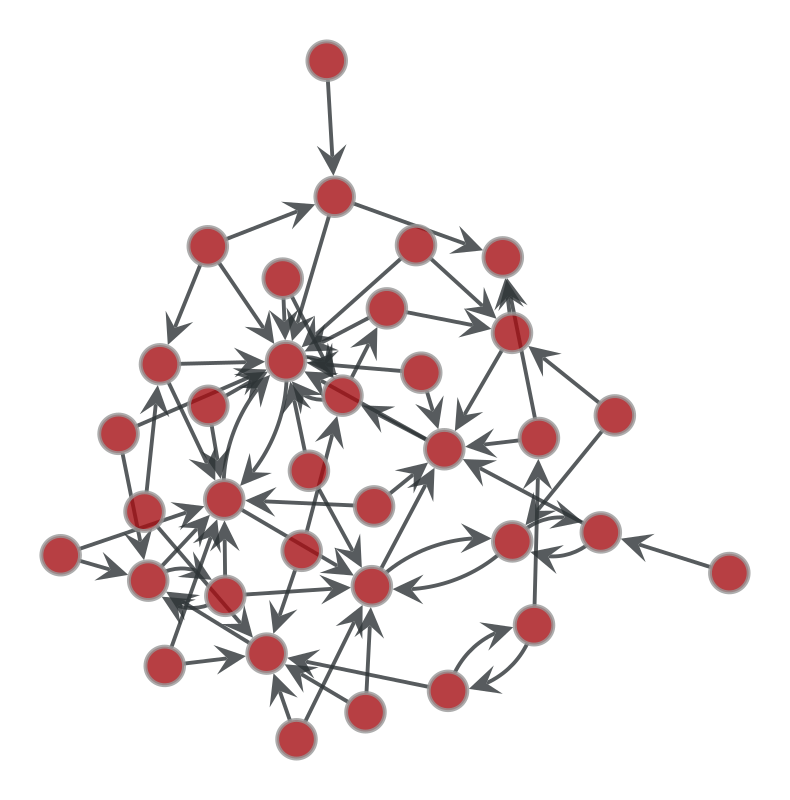

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e627560, at 0x1044bfe90>

In [4]:
graph_draw(g1, pos=g1.vp['_pos'], output_size=(400, 400))

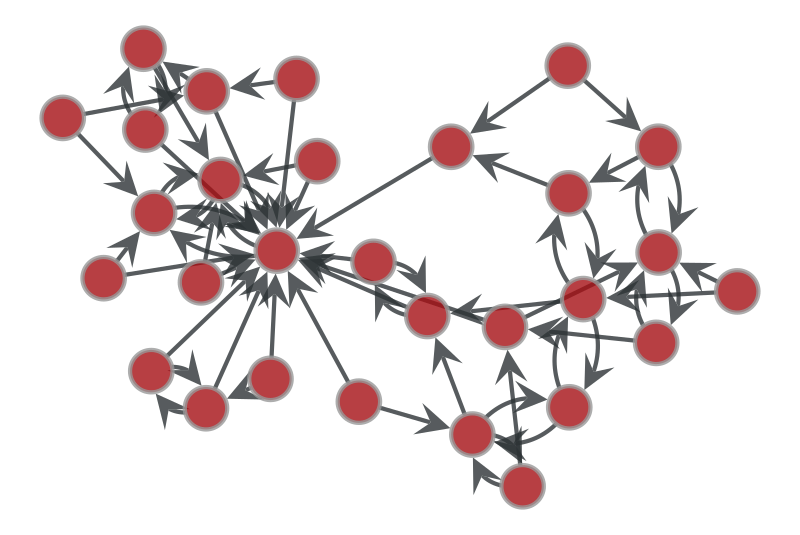

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e51d1f0, at 0x16e65af00>

In [5]:
graph_draw(g2, pos=g2.vp['_pos'], output_size=(400, 400))

In [6]:
list(g1.properties)

[('v', 'name'),
 ('v', '_pos'),
 ('g', 'name'),
 ('g', 'description'),
 ('g', 'citation'),
 ('g', 'url'),
 ('g', 'upstream_license'),
 ('g', 'tags')]

However the basis of OnionNet is to read data in through pandas dataframes. So we do that here now to recreate the above graph. We will also rename the columns while we're at it.

## Creating an OnionNet object using pandas dfs

Here we create a helper function to parse the data from the individual node or edge dataframes.

In [7]:
def get_school_data(edges_or_nodes, grade, convert_to_str=False):
    if edges_or_nodes=='edges':
        df = pd.read_csv(f'.data/example_moreno_sociograms/grade_{grade}/edges.csv', sep=',', header=0)
        df.columns = ['source_id', 'target_id']
    elif edges_or_nodes=='nodes':
        df = pd.read_csv(f'.data/example_moreno_sociograms/grade_{grade}/nodes.csv', sep=',', header=0)
        df.columns = ['node_id', 'name', '_pos']
    else:
        raise ValueError("edges_or_nodes must be 'edges' or 'nodes', and a valid grade must be provided")
    # Here we will also convert all values to string
    if convert_to_str:
        for col in df.columns:
            df[col] = df[col].astype(str)
    return df

In [8]:
print(get_school_data('nodes', 1).shape)
get_school_data('nodes', 1).head(10)

(35, 3)


,node_id,name,_pos
0,0,GO1,"array([-2.98488506, 0.86791962])"
1,1,LP,"array([-2.95675841, 1.34825587])"
2,2,PR,"array([-3.55699067, 3.00557276])"
3,3,WO,"array([-3.34686456, 2.41781597])"
4,4,FA1,"array([-3.19714822, 2.96207321])"
5,5,CA,"array([-3.72010476, 2.18584599])"
6,6,CE,"array([-3.1286156 , 1.92922718])"
7,7,HN1,"array([-3.61538221, 2.70444297])"
8,8,FA2,"array([-2.36291912, 1.56251772])"
9,9,FI,"array([-2.66954048, 1.51927661])"


Now let's say we want to create a multilayered network with the different classes from the school. To do this we will need to concatenate the dataframes.

In [9]:
NUM_GRADES = 2

In [10]:
df_nodes = pd.concat([get_school_data('nodes', i).assign(
    layer=f'grade_{i}') 
    for i in range(1, NUM_GRADES+1)], ignore_index=True)
df_nodes

,node_id,name,_pos,layer
0,0,GO1,"array([-2.98488506, 0.86791962])",grade_1
1,1,LP,"array([-2.95675841, 1.34825587])",grade_1
2,2,PR,"array([-3.55699067, 3.00557276])",grade_1
3,3,WO,"array([-3.34686456, 2.41781597])",grade_1
4,4,FA1,"array([-3.19714822, 2.96207321])",grade_1
...,...,...,...,...
59,24,SH,"array([ 1.60443291, -15.45916702])",grade_2
60,25,HF,"array([ 1.50660581, -15.28444862])",grade_2
61,26,FS,"array([ 1.4128519 , -15.46739683])",grade_2
62,27,AT,"array([ 1.83319756, -15.69773967])",grade_2


In [11]:
df_edges = pd.concat([get_school_data('edges', i).assign(
    source_layer=f'grade_{i}', 
    target_layer=f'grade_{i}',
    interlayer=False)
    for i in range(1, NUM_GRADES+1)], ignore_index=True)
df_edges

,source_id,target_id,source_layer,target_layer,interlayer
0,0,1,grade_1,grade_1,False
1,1,8,grade_1,grade_1,False
2,1,6,grade_1,grade_1,False
3,2,3,grade_1,grade_1,False
4,2,4,grade_1,grade_1,False
...,...,...,...,...,...
121,26,20,grade_2,grade_2,False
122,27,5,grade_2,grade_2,False
123,27,17,grade_2,grade_2,False
124,28,9,grade_2,grade_2,False


From this we can create an OnionNet graph

In [12]:
onion1 = OnionNet()

onion1.grow_onion(df_nodes=df_nodes,
           df_edges=df_edges,
           node_prop_cols=df_nodes.columns.to_list(),
           edge_prop_cols=df_edges.columns.to_list(),
           drop_na=True,
           drop_duplicates=True)

Nodes: in=64, dropped_na=0, deduped=0 → final=64
Edges: in=126, dropped_invalid=0, deduped=0 → final=126


To get a consistent layout for the graph we can use:

`pos_sfdp = gt.sfdp_layout(onion1.core.graph)`

Which will give us a standardised force-directed layout for the session and for this graph. But it will not be saved for the next session unless we do this with OnionNet, or generate it on the fly and save. In this tutorial we will load a pre-computed sfdp layout. 

__Beware however that this sfdp layout will be specific to your input dataframes and network. If you change the network or the input data for it, your `node_id_hash` or `layer_hash` will likely change.__

In [13]:
pos_sfdp = onionnet.visualisation.load_or_compute_layout(onion1.core.graph, filename='.getting_started_graph1_pos.tsv', override=False)

[load]   Loaded layout for 64 rows from .getting_started_graph1_pos.tsv


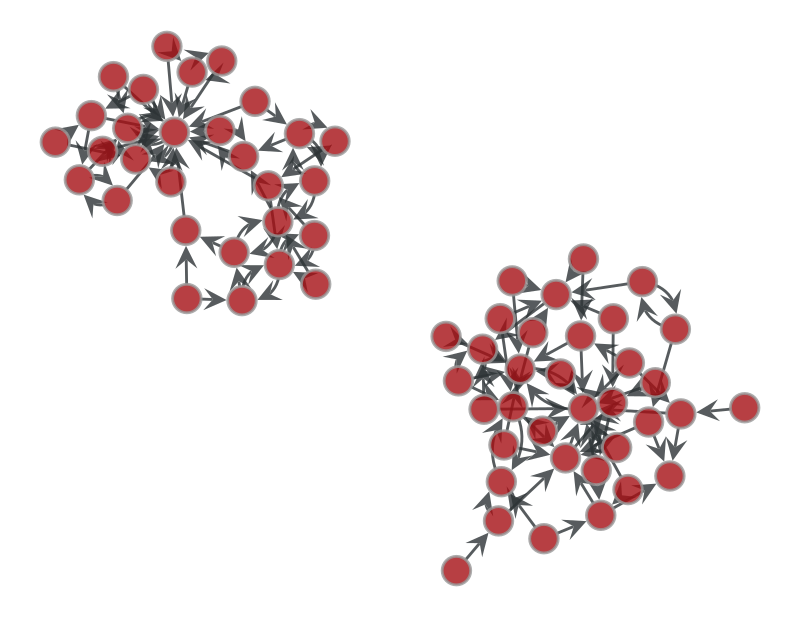

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e68e960, at 0x16e6c30e0>

In [14]:
graph_draw(onion1.core.graph, pos=pos_sfdp, output_size=(400, 400))

This is nice to see we have both our layers (i.e. grades) in the network. But it's also clear to see they're disconnected. Let's simulate a scenario where some students in each grade are friends or siblings with those from other grades.

## Multiple layers with interlayer connections

In [15]:
import numpy as np
import pandas as pd

def add_random_interlayer_edges(df_nodes, df_edges, num_interlayer_edges=10, seed=42):
    """
    Add random interlayer edges to an existing edges DataFrame.
    
    Parameters:
    - df_nodes: DataFrame containing nodes with at least 'id' and 'grade' columns.
    - df_edges: Existing edges DataFrame.
    - num_interlayer_edges: Number of random interlayer edges to create.
    - seed: Random seed for reproducibility.
    
    Returns:
    - Updated df_edges with added interlayer edges.
    """
    np.random.seed(seed)
    
    # Get unique grades from the nodes DataFrame.
    grades = df_nodes['layer'].unique()
    random_edges = []
    
    for _ in range(num_interlayer_edges):
        # Randomly select two different grades.
        source_grade, target_grade = np.random.choice(grades, size=2, replace=False)
        
        # Get nodes corresponding to each grade.
        source_nodes = df_nodes[df_nodes['layer'] == source_grade]
        target_nodes = df_nodes[df_nodes['layer'] == target_grade]
        
        # If one of the grades doesn't have any nodes, skip this iteration.
        if source_nodes.empty or target_nodes.empty:
            continue
        
        # Randomly select one node from each grade (assumes 'id' column exists).
        source_node = source_nodes.sample(n=1).iloc[0]['node_id']
        target_node = target_nodes.sample(n=1).iloc[0]['node_id']
        
        # Append a new interlayer edge.
        random_edges.append({
            'source_id': source_node,
            'target_id': target_node,
            'source_layer': source_grade,
            'target_layer': target_grade,
            'interlayer': True
        })
    
    # Convert the list of random edges into a DataFrame.
    df_random_edges = pd.DataFrame(random_edges)
    
    # Concatenate the random interlayer edges with the existing edges.
    updated_df_edges = pd.concat([df_edges, df_random_edges], ignore_index=True)
    
    return updated_df_edges

# Now add random interlayer edges.
df_edges_with_friends = add_random_interlayer_edges(df_nodes, df_edges, num_interlayer_edges=10, seed=42)
df_edges_with_friends

,source_id,target_id,source_layer,target_layer,interlayer
0,0,1,grade_1,grade_1,False
1,1,8,grade_1,grade_1,False
2,1,6,grade_1,grade_1,False
3,2,3,grade_1,grade_1,False
4,2,4,grade_1,grade_1,False
...,...,...,...,...,...
131,17,17,grade_2,grade_1,True
132,4,15,grade_1,grade_2,True
133,9,10,grade_1,grade_2,True
134,14,26,grade_2,grade_1,True


In [16]:
onion2 = OnionNet()

onion2.grow_onion(df_nodes=df_nodes,
           df_edges=df_edges_with_friends,
           node_prop_cols=df_nodes.columns.to_list(),
           edge_prop_cols=df_edges_with_friends.columns.to_list(),
           drop_na=False,
           drop_duplicates=False)

Nodes: in=64, dropped_na=0, deduped=0 → final=64
Edges: in=136, dropped_invalid=0, deduped=0 → final=136


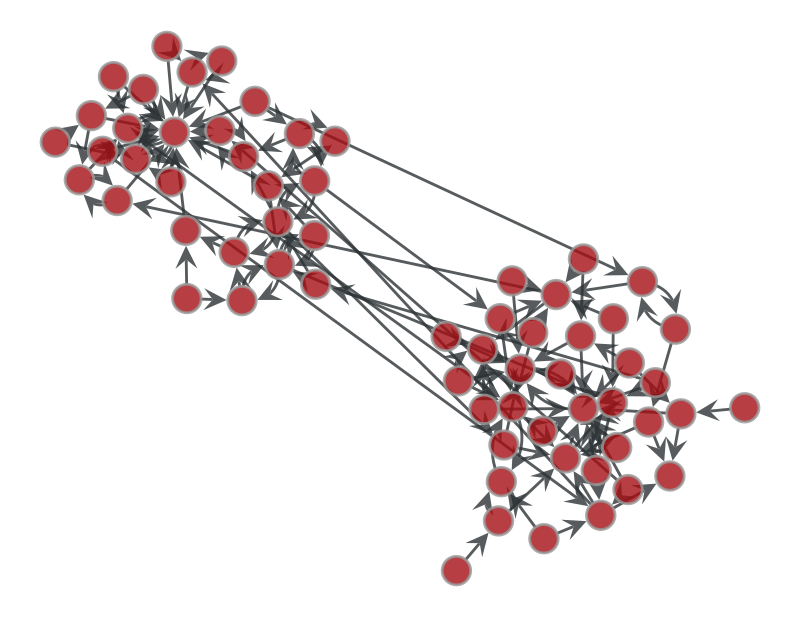

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e68f470, at 0x16e6c1d00>

In [17]:
graph_draw(onion2.core.graph, pos=pos_sfdp, output_size=(400, 400))

{'v_color': <VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e68f470, at 0x16e6c3f50>, 'legend_node_color': {0: (np.float64(0.12156862745098039), np.float64(0.4666666666666667), np.float64(0.7058823529411765), 1.0), 1: (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), 1.0)}}
{'e_color': <EdgePropertyMap object with value type 'vector<double>', for Graph 0x16e68f470, at 0x16cae0b60>, 'legend_edge_color': {'True': (1.0, 0.0, 0.0, 1.0), 'False': (0.5, 0.5, 0.5, 1.0)}}


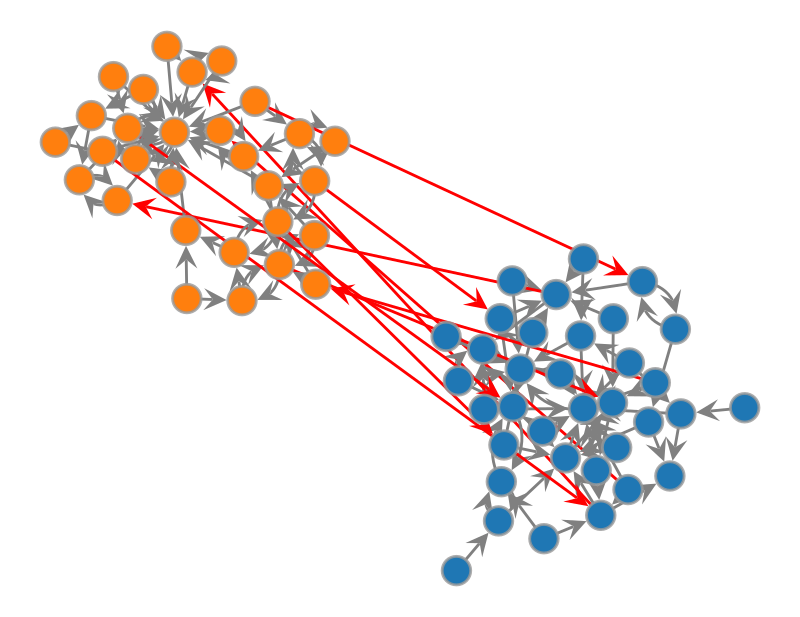

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e68f470, at 0x16e6c0170>

In [18]:
v_cols = onionnet.visualisation.color_nodes(g=onion2.core.graph, prop_name='layer', generate_legend=True)
e_cols = onionnet.visualisation.color_edges(g=onion2.core.graph, prop_name='interlayer', method='boolean', generate_legend=True)

print(v_cols)
print(e_cols)

graph_draw(onion2.core.graph, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=v_cols['v_color'], 
           edge_color=e_cols['e_color'])

Now it would be good to add labels to this to see the student names. We can do this using `vertex_text`.

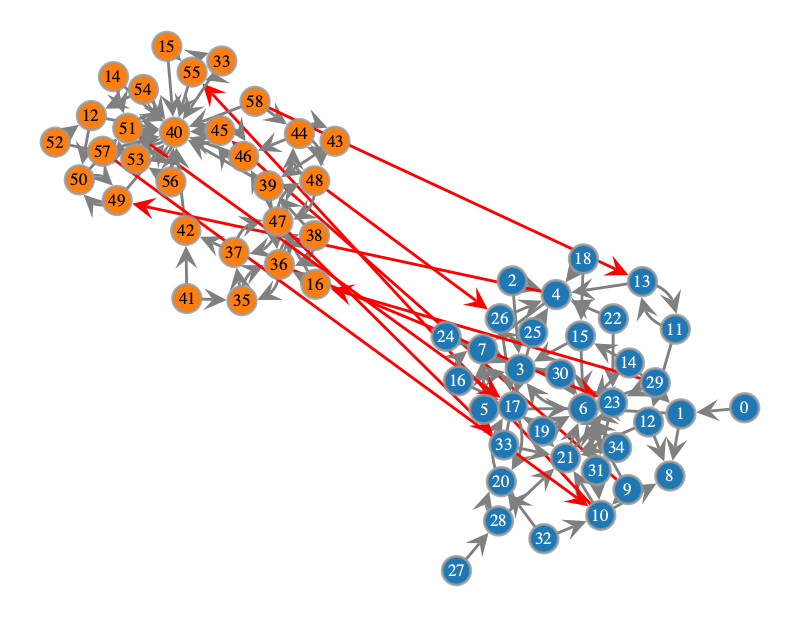

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e68f470, at 0x16e6c15e0>

In [19]:
graph_draw(onion2.core.graph, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=v_cols['v_color'], 
           edge_color=e_cols['e_color'],
           vertex_text=onion2.core.graph.vp['name'])

Oh no! Now all we have is numbers for the students. What has happened here? Let's look at our original nodes_df

In [20]:
df_nodes.groupby(['node_id', 'name']).last().drop(columns='_pos')

layer
node_id name         
0       GO1   grade_1
        ZV    grade_2
1       LP    grade_1
        MK    grade_2
2       LL    grade_2
...               ...
30      KR1   grade_1
31      EL    grade_1
32      SA    grade_1
33      HF    grade_1
34      TA    grade_1

[64 rows x 1 columns]

If we look closely we can also see that these are not the original node_ids in our plot, because in our nodes_id we had some node_ids that were actually the same for student's with different names!

So why did OnionNet treat these differently and what are the labels on the network plot? 

The answer is that behind the scenes OnionNet creates unique nodes based on both the node_id _and_ the layer. Then to improve efficiency, OnionNet encodes these values using the pandas df dtypes by default. So the node numbers we saw before are actually the mappings of these values to a dictionary we have in OnionNet. We can inspect these below.

In [21]:
onion2.core.vertex_categorical_mappings.keys()

dict_keys(['node_id', 'name', '_pos', 'layer'])

In [22]:
onion2.core.vertex_categorical_mappings['layer'].keys()

dict_keys(['str_to_int', 'int_to_str'])

In [23]:
onion2.core.vertex_categorical_mappings['layer']['str_to_int']

{'grade_1': 0, 'grade_2': 1}

In [24]:
print(onion2.core.vertex_categorical_mappings.keys())
print(onion2.core.edge_categorical_mappings.keys())

dict_keys(['node_id', 'name', '_pos', 'layer'])
dict_keys(['source_id', 'target_id', 'source_layer', 'target_layer', 'interlayer'])


To convert these integers back into their real values we have to decode them using the `decode_property_labels` function.

In [25]:
extra_vars = ['layer', 'node_id', 'name']
for var in extra_vars:
    onion2.prop_manager.decode_property_labels(
        encoded_prop_type='v', 
        encoded_prop_name=var
    )

V property 'layer_decoded' created successfully.
V property 'node_id_decoded' created successfully.
V property 'name_decoded' created successfully.


Note that these properties will be added to the vertex or edge properties of the graph directly

In [26]:
print(list(list(onion2.core.graph.vp)))
print(list(list(onion2.core.graph.ep)))

['layer_hash', 'node_id_hash', 'node_id', 'name', '_pos', 'layer', 'layer_decoded', 'node_id_decoded', 'name_decoded']
['source_id', 'target_id', 'source_layer', 'target_layer', 'interlayer']


You won't see them and they won't be added to the vertex or edge categorical mappings (because the categorical mappings are just mappings between the encoded values, not the values of the nodes or edge properties directly)

In [27]:
print(onion2.core.vertex_categorical_mappings.keys())
print(onion2.core.edge_categorical_mappings.keys())

dict_keys(['node_id', 'name', '_pos', 'layer'])
dict_keys(['source_id', 'target_id', 'source_layer', 'target_layer', 'interlayer'])


Now that we have the decoded properties in our vertex properties of the graph, we can try drawing the graph again, this time using the `name_decoded` vertex property

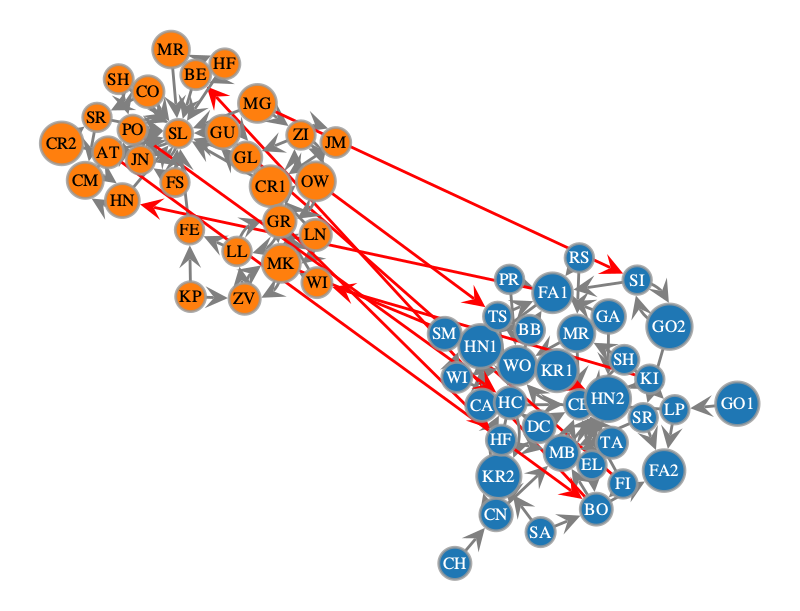

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e68f470, at 0x16e658e60>

In [28]:
graph_draw(onion2.core.graph, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=v_cols['v_color'], 
           edge_color=e_cols['e_color'],
           vertex_text=onion2.core.graph.vp['name_decoded'])

We should also generate a legend for this too, so we know which category is which

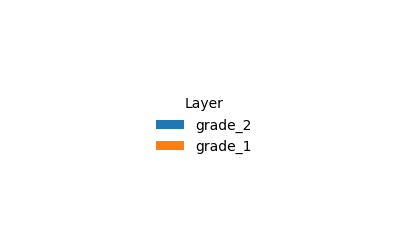

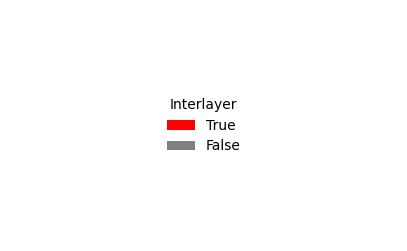

In [29]:
onionnet.visualisation.get_legend(onion2.core.graph, prop='layer_decoded', title='Layer')
onionnet.visualisation.get_legend(source=e_cols['legend_edge_color'], title='Interlayer')

## Filtering the multi-layer network by layers

Now what if we want to filter the network in some ways, for example get a single layer, or multiple layers?

To filter and view certain layers of the network we can use the OnionNet `searcher.view_layers` function.

In [30]:
filtered_layers_gv = onion2.searcher.view_layers(layer_names=['grade_1'])
filtered_layers_gv

<GraphView object, directed, with 35 vertices and 67 edges, 9 internal vertex properties, 5 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x16e6d35c0, at 0x1044f91f0>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x16e6d35c0, at 0x177e8f5c0>, False), at 0x16e6d35c0>

This returns a GraphView object.

We could also just create a vertex property map (but for now we will not use it)

In [31]:
filtered_layers_vpm = onion2.searcher.view_layers(layer_names=['grade_1'], return_filter=True)
filtered_layers_vpm

<VertexPropertyMap object with value type 'bool', for Graph 0x16e68f470, at 0x177e368d0>

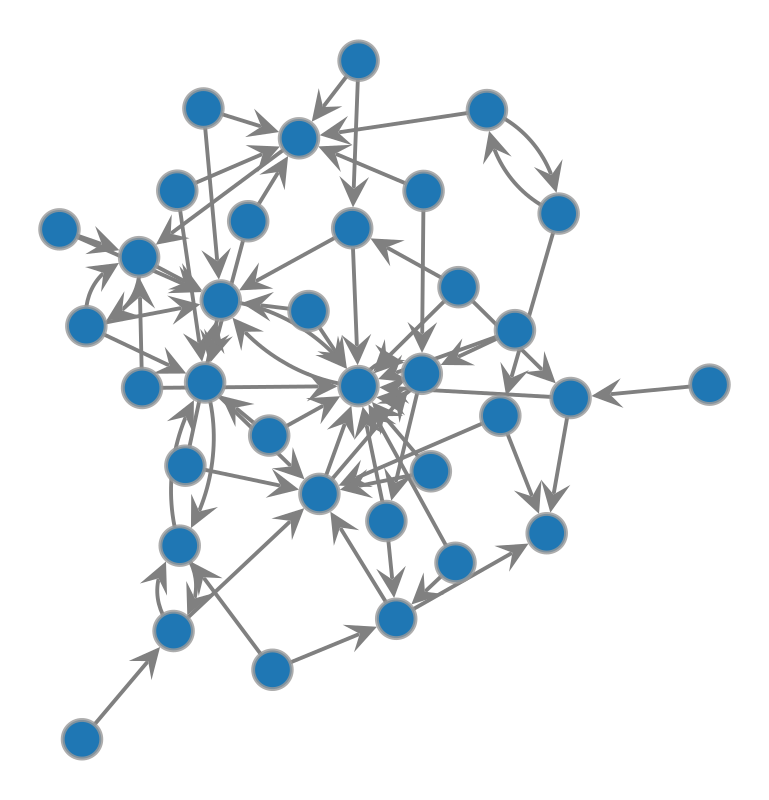

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e6d35c0, at 0x177e8f2f0>

In [32]:
graph_draw(filtered_layers_gv, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=v_cols['v_color'], 
           edge_color=e_cols['e_color']) #,
           #vertex_text=filtered_layers.core.graph.vp['name_decoded'])

The graph view has all the same properties as before

In [33]:
list(filtered_layers_gv.vertex_properties)

['layer_hash',
 'node_id_hash',
 'node_id',
 'name',
 '_pos',
 'layer',
 'layer_decoded',
 'node_id_decoded',
 'name_decoded']

But if you try running the function below you will get an error:

`ValueError: could not broadcast input array from shape (64,) into shape (35,)`

In [34]:
# graph_draw(filtered_layers_gv, 
#            pos=pos_sfdp, 
#            output_size=(400, 400),
#            vertex_fill_color=v_cols['v_color'], 
#            edge_color=e_cols['e_color'],
#            vertex_text=filtered_layers_gv.vp['name_decoded'])

This is because the property maps that we had before for colour of the edges and nodes were for the full graph. Since these were not attached as a vertex or edge property to the graph, the filtered graph layer operation that we did has resulted in the filter being different in shape to the colour property maps.

To overcome this, we have two options:
1. recompute the vertex or edge properties using the filtered graph
2. assign the color property maps to the original graph before filtering

Your choice of these depends on whether you think you will be using the property for long or just want it on the fly

### Option 1) recalculating property maps

In [35]:
v_cols2 = onionnet.visualisation.color_nodes(g=filtered_layers_gv, prop_name='layer')
e_cols2 = onionnet.visualisation.color_edges(g=filtered_layers_gv, prop_name='interlayer', method='boolean')

print(v_cols2)
print(e_cols2)

{'v_color': <VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e6d35c0, at 0x177e8eb10>, 'legend_node_color': None}
{'e_color': <EdgePropertyMap object with value type 'vector<double>', for Graph 0x16e6d35c0, at 0x1044f9760>, 'legend_edge_color': None}


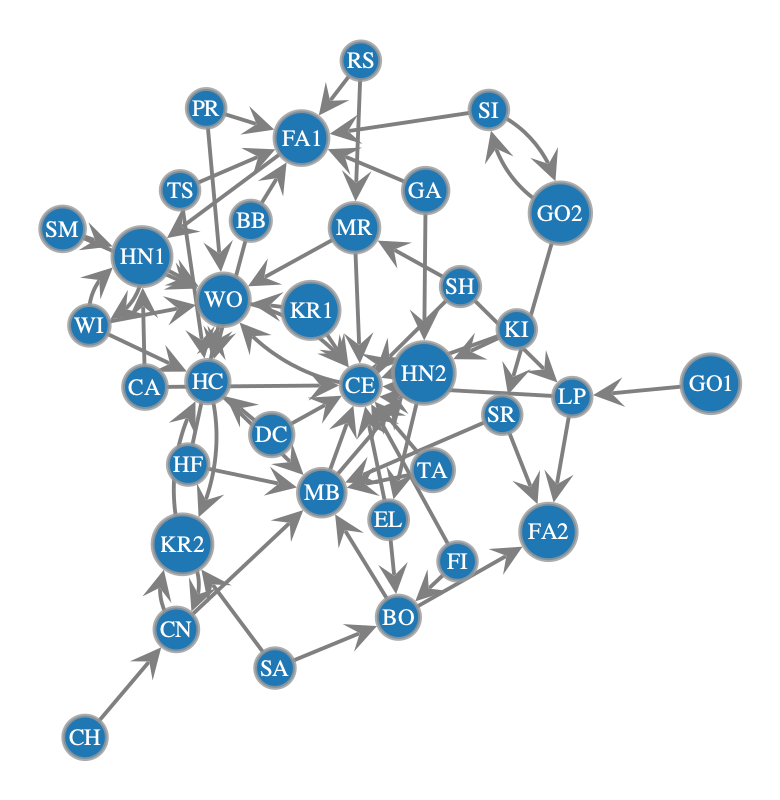

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e6d35c0, at 0x177e44230>

In [36]:
graph_draw(filtered_layers_gv, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=v_cols2['v_color'], 
           edge_color=e_cols2['e_color'],
           vertex_text=filtered_layers_gv.vp['name_decoded'])

### Option 2) assigning property maps before filtering

In [37]:
onion2.core.graph.vp['v_color'] = v_cols['v_color']
onion2.core.graph.ep['e_color'] = e_cols['e_color']

In [38]:
filtered_layers_gv2 = onion2.searcher.view_layers(layer_names=['grade_1'])
filtered_layers_gv2

<GraphView object, directed, with 35 vertices and 67 edges, 10 internal vertex properties, 6 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x16e68ec00, at 0x16e6c1640>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x16e68ec00, at 0x16e6c1400>, False), at 0x16e68ec00>

In [39]:
print(list(filtered_layers_gv2.vp))
print(list(filtered_layers_gv2.ep))

['layer_hash', 'node_id_hash', 'node_id', 'name', '_pos', 'layer', 'layer_decoded', 'node_id_decoded', 'name_decoded', 'v_color']
['source_id', 'target_id', 'source_layer', 'target_layer', 'interlayer', 'e_color']


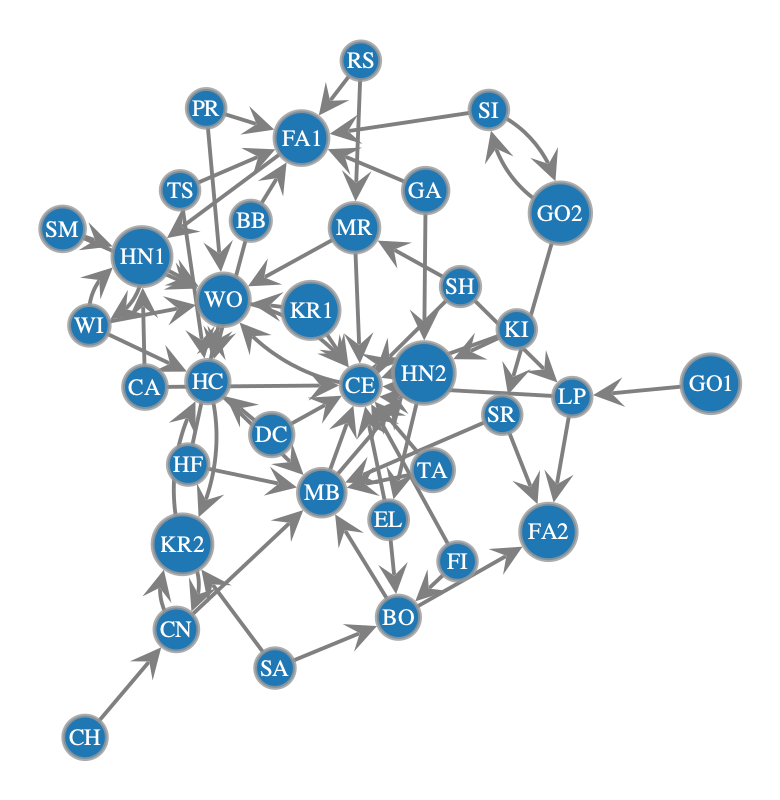

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e68ec00, at 0x16e68f7a0>

In [40]:
graph_draw(filtered_layers_gv2, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=filtered_layers_gv2.vp['v_color'], 
           edge_color=filtered_layers_gv2.ep['e_color'],
           vertex_text=filtered_layers_gv2.vp['name_decoded'])

## Searching and filtering the network by nodes

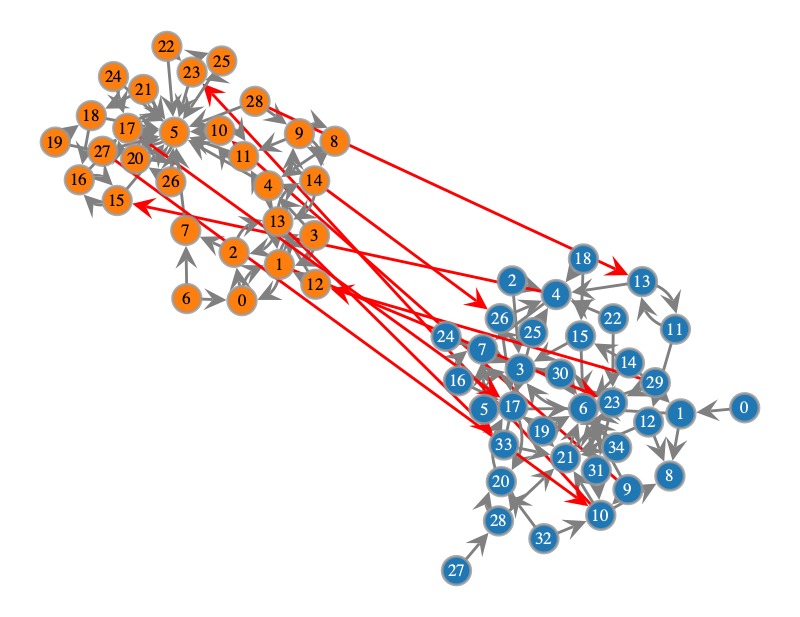

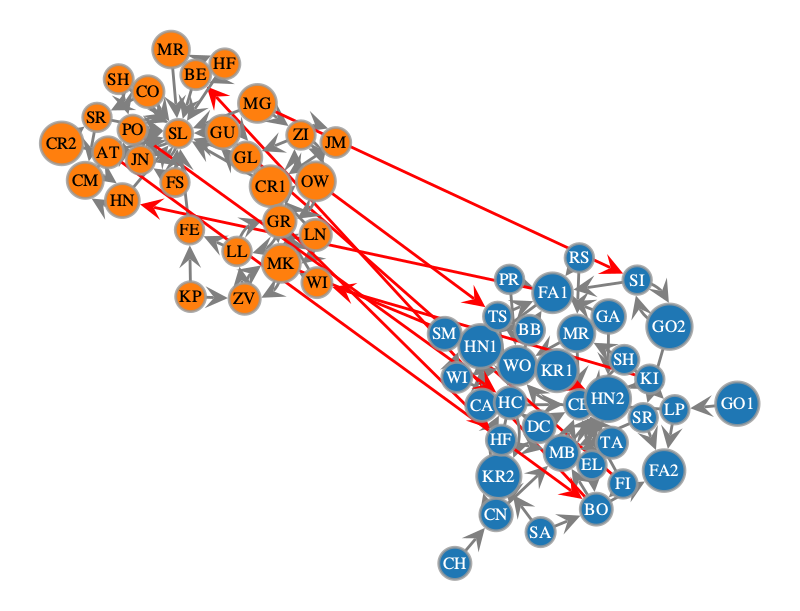

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e68f470, at 0x177e6e1e0>

In [41]:
graph_draw(onion2.core.graph, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=v_cols['v_color'], 
           edge_color=e_cols['e_color'],
           vertex_text=onion2.core.graph.vp['node_id'])

graph_draw(onion2.core.graph, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=v_cols['v_color'], 
           edge_color=e_cols['e_color'],
           vertex_text=onion2.core.graph.vp['name_decoded'])

Now we can run a search

Filtered graph contains 11 vertices and 18 edges.


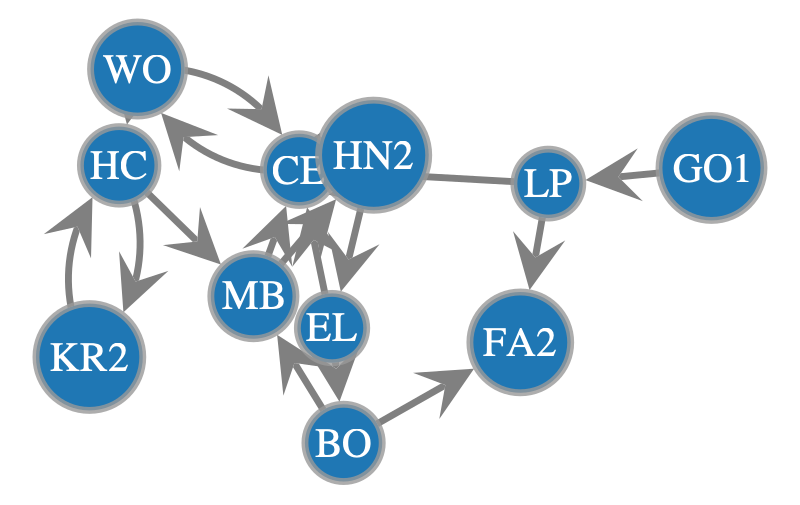

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x177e45040, at 0x1044f13a0>

In [42]:
node_search_res = onion2.searcher.search(show_plot=False)

graph_draw(node_search_res, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=node_search_res.vp['v_color'], 
           edge_color=node_search_res.ep['e_color'],
           vertex_text=node_search_res.vp['name_decoded'])

By default, you will see that search used the 0 index starting node if we don't provide it with any more information. Furthermore, by default it only traverses downstream of the network up to 5 steps. We could try extending this.

Filtered graph contains 15 vertices and 26 edges.


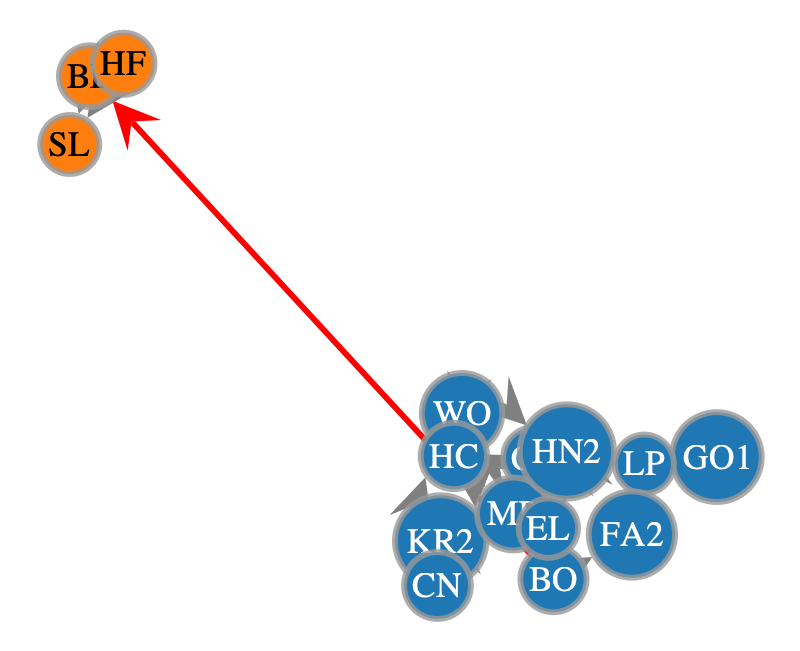

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x177ebe420, at 0x16e65b170>

In [43]:
node_search_res = onion2.searcher.search(show_plot=False,
                                         max_dist=7)

graph_draw(node_search_res, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=node_search_res.vp['v_color'], 
           edge_color=node_search_res.ep['e_color'],
           vertex_text=node_search_res.vp['name_decoded'])

What if we extend a bit more?

Filtered graph contains 17 vertices and 33 edges.


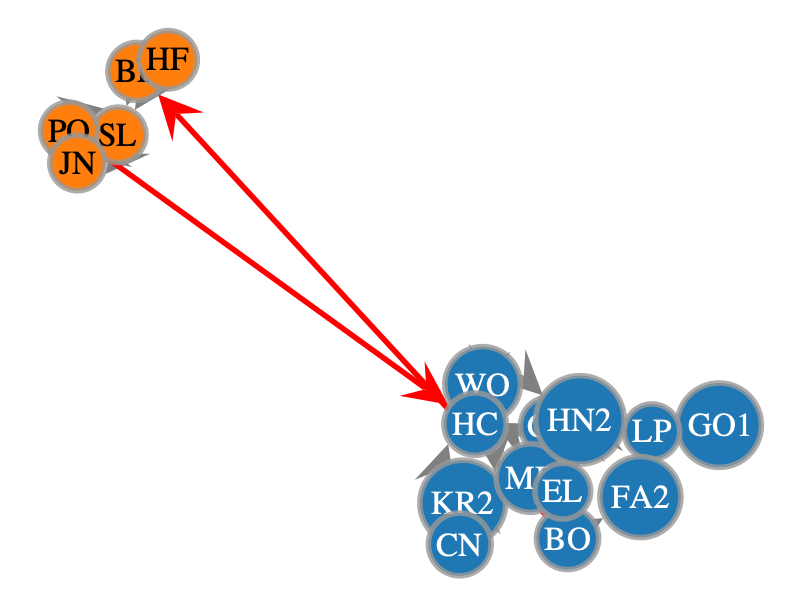

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e6c0f80, at 0x177e6e5a0>

In [44]:
node_search_res = onion2.searcher.search(show_plot=False,
                                         max_dist=10)

graph_draw(node_search_res, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=node_search_res.vp['v_color'], 
           edge_color=node_search_res.ep['e_color'],
           vertex_text=node_search_res.vp['name_decoded'])

We could also try starting with a different index

Filtered graph contains 3 vertices and 2 edges.


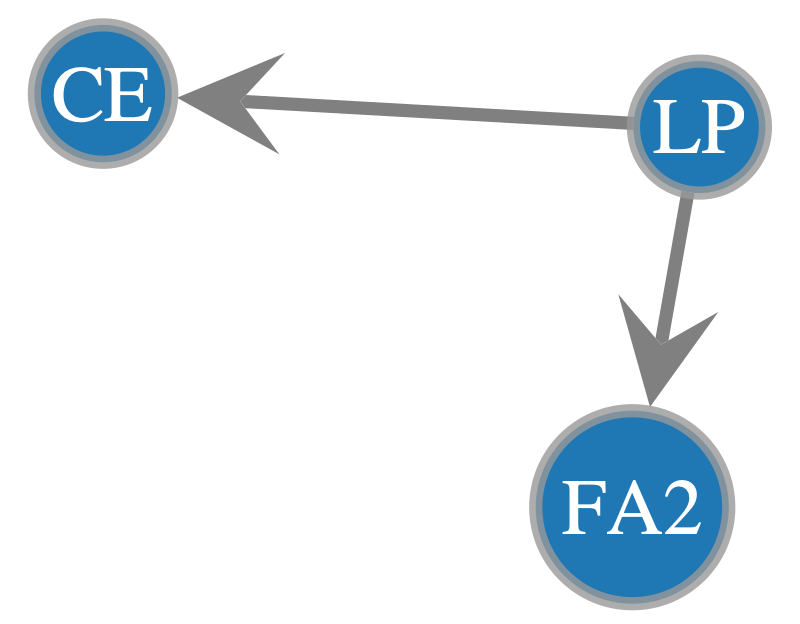

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x177e37bc0, at 0x16e6c0f80>

In [45]:
node_search_res = onion2.searcher.search(show_plot=False,
                                         start_node_idx=1,
                                         max_dist=1)

graph_draw(node_search_res, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=node_search_res.vp['v_color'], 
           edge_color=node_search_res.ep['e_color'],
           vertex_text=node_search_res.vp['name_decoded'])

And we could also search upstream or bidirectionally

Filtered graph contains 5 vertices and 5 edges.


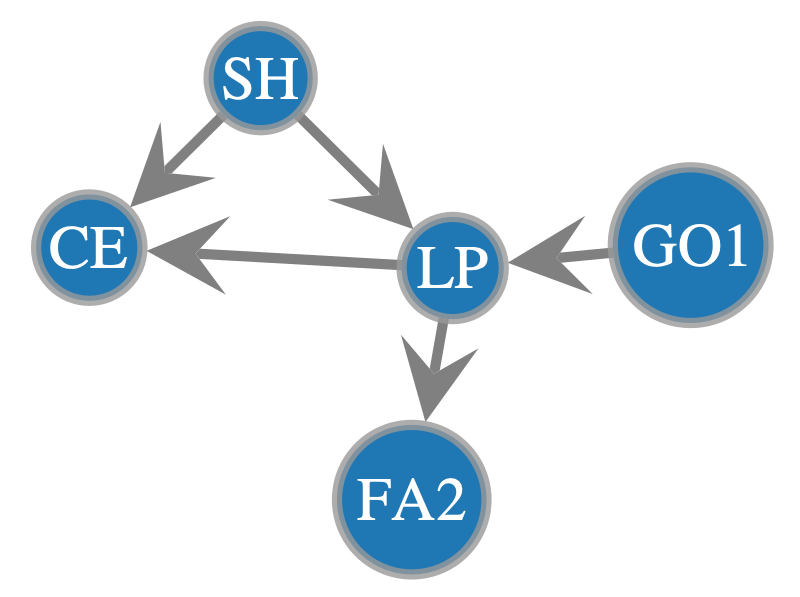

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x177ebed80, at 0x177e44500>

In [46]:
node_search_res = onion2.searcher.search(show_plot=False,
                                         start_node_idx=1,
                                         direction='bi',
                                         max_dist=1)

graph_draw(node_search_res, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=node_search_res.vp['v_color'], 
           edge_color=node_search_res.ep['e_color'],
           vertex_text=node_search_res.vp['name_decoded'])

We could also get all nodes that meet a certain condition, such as all nodes that are in a list of names.

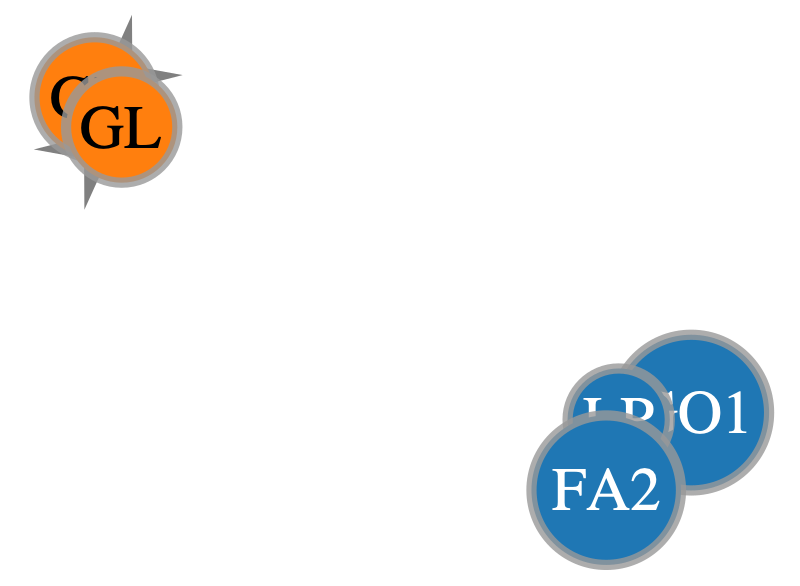

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x177ebf380, at 0x177e6f140>

In [47]:
random_friends_gv = onion2.searcher.filter_view_by_property(
    prop_name='name_decoded', 
    target_value=['GO1', 'LP', 'FA2','GL','GU'])

graph_draw(random_friends_gv, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=random_friends_gv.vp['v_color'], 
           edge_color=random_friends_gv.ep['e_color'],
           vertex_text=random_friends_gv.vp['name_decoded'])

In [48]:
list(random_friends_gv.vertices())

[<Vertex object with index '0' at 0x177e3ff40>,
 <Vertex object with index '1' at 0x177e3fcc0>,
 <Vertex object with index '8' at 0x177e3eec0>,
 <Vertex object with index '45' at 0x177ee0ac0>,
 <Vertex object with index '46' at 0x177ee09c0>]

In [49]:
list(random_friends_gv.vertices())[0].out_degree()

1

We could also filter the graph according to some edge attribute condition. In this case we will test with interlayer, to only show the connections between kids in the 1st and 2nd grade.

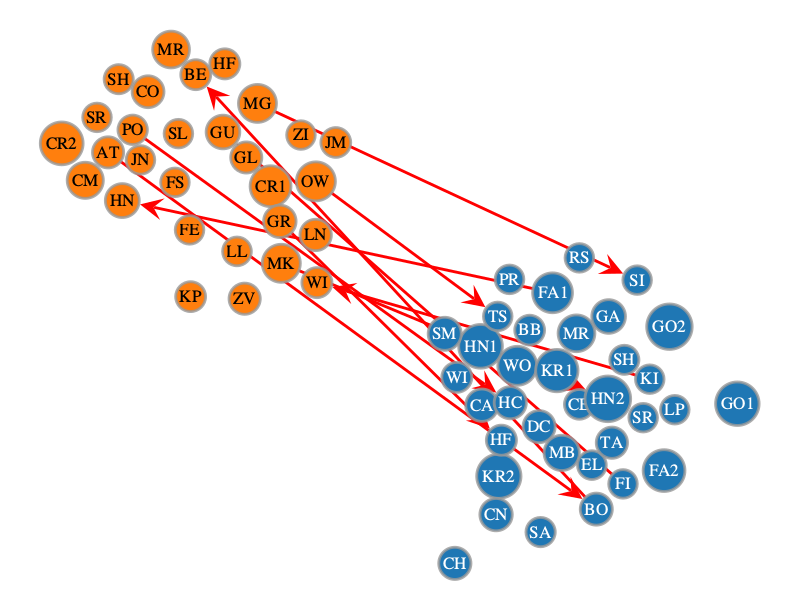

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x177ebf080, at 0x16e6d2f60>

In [50]:
interlayer_friends_gv = onion2.searcher.filter_view_by_property(
    prop_name='interlayer', 
    target_value=True,
    dim='e')

graph_draw(interlayer_friends_gv, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=interlayer_friends_gv.vp['v_color'], 
           edge_color=interlayer_friends_gv.ep['e_color'],
           vertex_text=interlayer_friends_gv.vp['name_decoded'])

Note that by default this function doesn't automatically remove the nodes that are isolated with no edges connecting them. If we want to do that we should specify `prune_isolated=True`

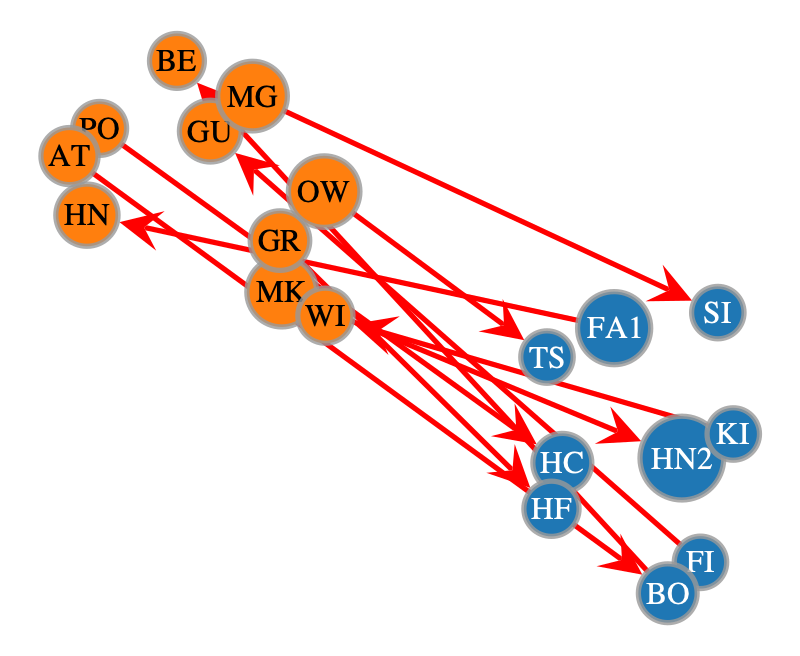

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x303a08d40, at 0x177e36c00>

In [51]:
interlayer_friends_gv_pruned = onion2.searcher.filter_view_by_property(
    prop_name='interlayer', 
    target_value=True,
    dim='e',
    prune_isolated=True)

graph_draw(interlayer_friends_gv_pruned, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=interlayer_friends_gv_pruned.vp['v_color'], 
           edge_color=interlayer_friends_gv_pruned.ep['e_color'],
           vertex_text=interlayer_friends_gv_pruned.vp['name_decoded'])

Another way that we can filter the graph, if we wish to use more advanced logic, is to use lambda functions. OnionNet provides a helper function as well to combine these functions. For instance, we could filter to have either grade_1 or grade_2:

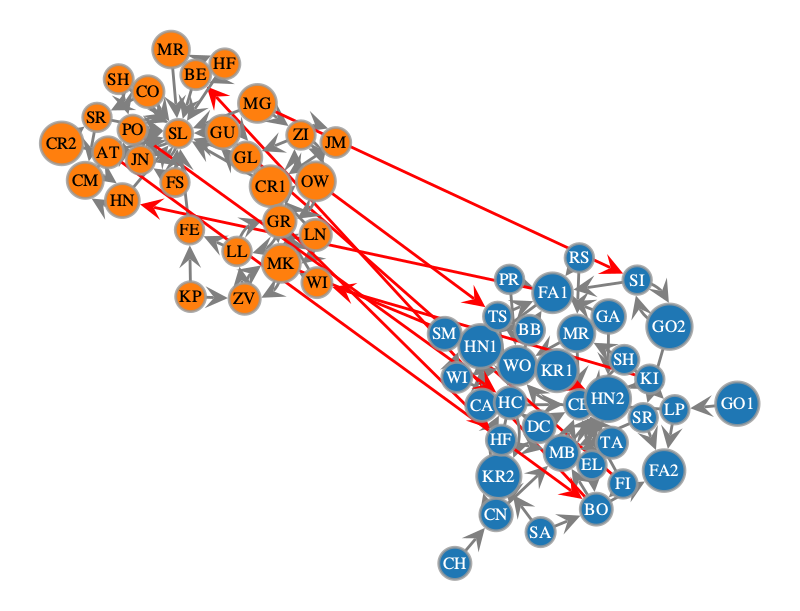

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x303a093d0, at 0x16e51c290>

In [52]:
filter1 = lambda v: onion2.core.graph.vp['layer_decoded'][v] == 'grade_1'
filter2 = lambda v: onion2.core.graph.vp['layer_decoded'][v] == 'grade_2'
filtered_view = onion2.searcher.compose_filters([filter1, filter2], mode="or")

graph_draw(filtered_view, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=filtered_view.vp['v_color'], 
           edge_color=filtered_view.ep['e_color'],
           vertex_text=filtered_view.vp['name_decoded'])

Or filter to the interlayer friends from before, but this time only show the ones in grade_1, we could try the method below...

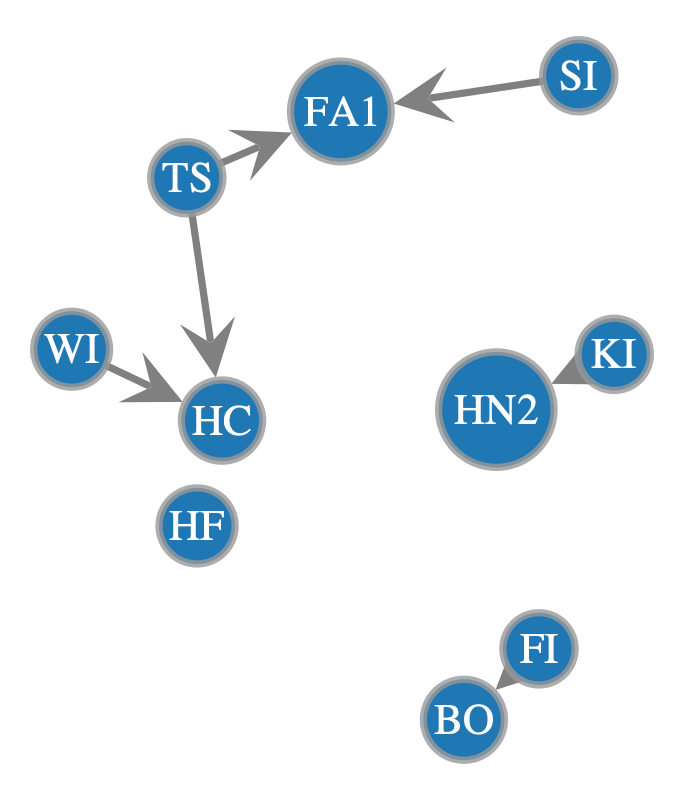

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x303a0a960, at 0x177e8f6b0>

In [53]:
filter1 = lambda v: onion2.core.graph.vp['layer_decoded'][v] == 'grade_1'
filter2 = lambda v: onion2.core.graph.vp['name_decoded'][v] in {interlayer_friends_gv_pruned.vp['name_decoded'][item] for item in interlayer_friends_gv_pruned.vertices()}
filtered_view = onion2.searcher.compose_filters([filter1, filter2], mode="and")

graph_draw(filtered_view, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=filtered_view.vp['v_color'], 
           edge_color=filtered_view.ep['e_color'],
           vertex_text=filtered_view.vp['name_decoded'])

But if we inspect this carefully, we will see that the blue grade 1 node labelled `WI` has been included, even though it wasn't in `interlayer_friends_gv_pruned`! Why is this?

The answer is that because the method above used the decoded_names, there was another child called `WI` in the other grade that was also included in the `interlayer_friends_gv_pruned`. So the `AND` condition we used for the filtered condition included both `WI` children, but only selected the one in Grade 1. Also if we used something like the `node_id` this problem would have been even more widespread, because many of the nodes share the same ID's but are in different layers!

__This is a cautionary tale: we need to be careful about what conditions we are using for filtering and think about possible edge cases__. Luckily in this case we were able to diagnose the problem, but on a much larger or complex graph you can imagine this could be much more difficult. 

To fix this we will use the actual vertices themselves, which are handled more unambiguously by graph-tool.

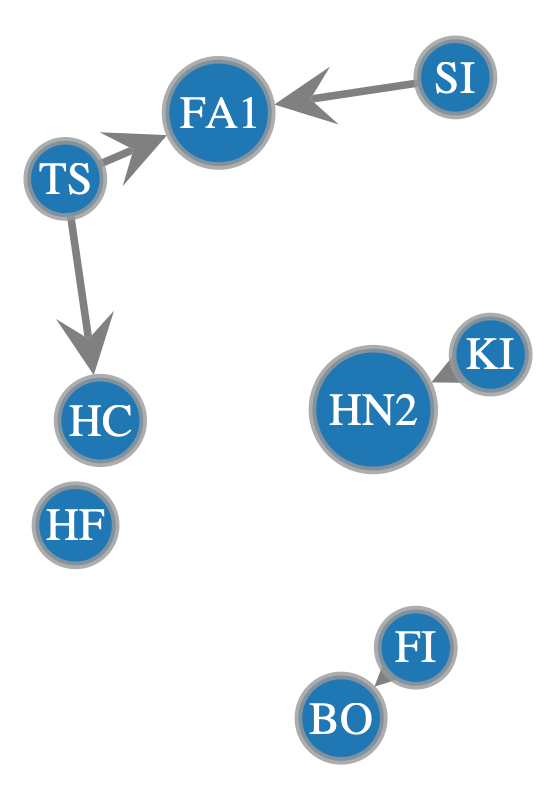

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x303a0aba0, at 0x177ebe6f0>

In [54]:
filter1 = lambda v: onion2.core.graph.vp['layer_decoded'][v] == 'grade_1'
pruned_vs = set(interlayer_friends_gv_pruned.vertices())
filter2 = lambda v: v in pruned_vs

filtered_view = onion2.searcher.compose_filters([filter1, filter2], mode="and")

graph_draw(filtered_view, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=filtered_view.vp['v_color'], 
           edge_color=filtered_view.ep['e_color'],
           vertex_text=filtered_view.vp['name_decoded'])

In [55]:
filtered_view

<GraphView object, directed, with 9 vertices and 5 edges, 10 internal vertex properties, 6 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x303a0aba0, at 0x303a0b020>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x303a0aba0, at 0x303a09e80>, False), at 0x303a0aba0>

Great, now we have the same nodes from earlier that were in the `interlayer_friends_gv_pruned` view, but this time only for those in Grade 1.

## Shortest paths

If we want to find the shortest path between a given node and a collection of other nodes we can do it using the `compute_on_shortest()` method.

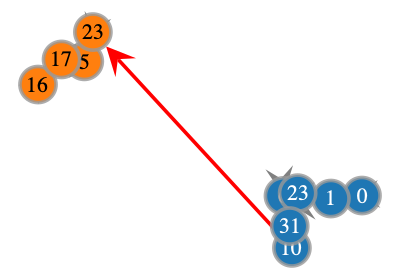

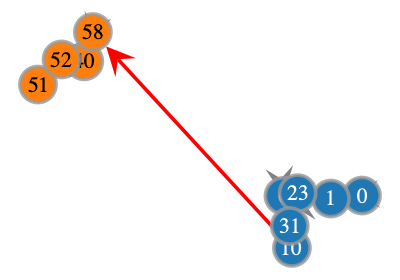

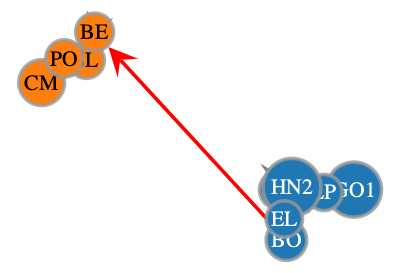

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x177e8f350, at 0x177ebd9a0>

In [56]:
# Compute shortest path between the source idx and the target indices - returns a vertex property map
shortest_path_vpm = onion2.searcher.compute_on_shortest(source_idx=0, target_indices=[51,52])
# Filter a graphview to the
shortest_path_gv = gt.GraphView(onion2.core.graph, vfilt=shortest_path_vpm)

# Show the same shortest path graphview with different attributes as the nodes
# Node ID
graph_draw(shortest_path_gv, 
           pos=pos_sfdp, 
           output_size=(200, 200),
           vertex_fill_color=shortest_path_gv.vp['v_color'], 
           edge_color=shortest_path_gv.ep['e_color'],
           vertex_text=shortest_path_gv.vp['node_id'])
# Vertex Index
graph_draw(shortest_path_gv, 
           pos=pos_sfdp, 
           output_size=(200, 200),
           vertex_fill_color=shortest_path_gv.vp['v_color'], 
           edge_color=shortest_path_gv.ep['e_color'],
           vertex_text=onion2.core.graph.vertex_index)
# Name (decoded)
graph_draw(shortest_path_gv, 
           pos=pos_sfdp, 
           output_size=(200, 200),
           vertex_fill_color=shortest_path_gv.vp['v_color'], 
           edge_color=shortest_path_gv.ep['e_color'],
           vertex_text=shortest_path_gv.vp['name_decoded'])

Notice above how the vertex index is different to the category mapping of the node, which we should keep in mind.

In [57]:
print(onion2.get_vertex_by_name_tuple(layer_name='grade_1', node_id_str='0'))
print(onion2.get_vertex_by_name_tuple(layer_name='grade_2', node_id_str='0'))

0
35


Ok now what if we want to find the path between a particular index and a bunch of different indices? We can use our list(random_friends_gv.vertices()) from earlier to find connections here between these

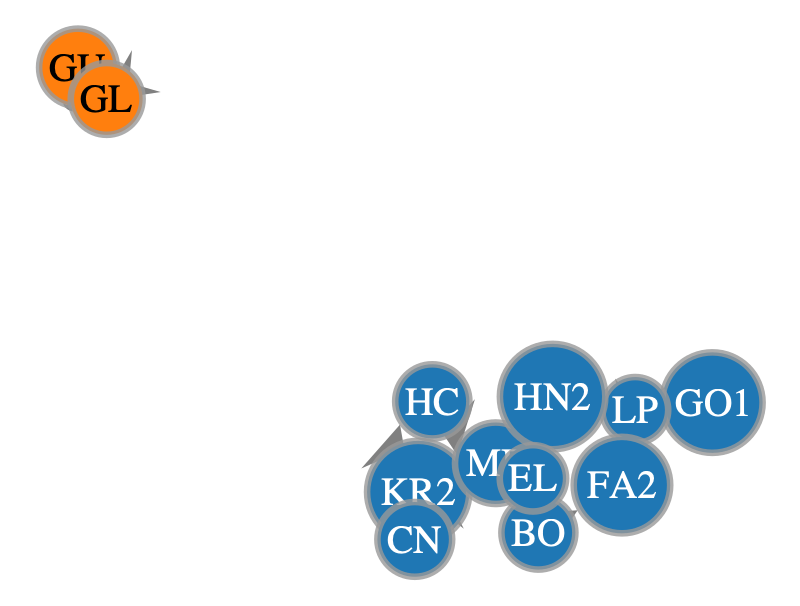

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e6d3b00, at 0x177e44380>

In [58]:
random_friends_gv_idxlist = [int(item) for item in random_friends_gv.vertices()]

shortest_path_vpm2 = onion2.searcher.compute_on_shortest(source_idx=20, target_indices=random_friends_gv_idxlist)

shortest_path_gv2 = gt.GraphView(onion2.core.graph, vfilt=shortest_path_vpm2)


graph_draw(shortest_path_gv2, 
           pos=pos_sfdp, 
           output_size=(400, 400),
           vertex_fill_color=shortest_path_gv2.vp['v_color'], 
           edge_color=shortest_path_gv2.ep['e_color'],
           vertex_text=shortest_path_gv2.vp['name_decoded'])

In [59]:
onion2.core.graph.vp['node_id'].a

PropertyArray([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14,
               15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29,
               30, 31, 32, 33, 34,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
               10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
               25, 26, 27, 28], dtype=int32)

What about combining operations? So filtering to a certain layer of the network and then performing a search.

In [60]:
onion2.view_layers(['grade_1'])

<GraphView object, directed, with 35 vertices and 67 edges, 10 internal vertex properties, 6 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x303a28320, at 0x303a0a6c0>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x303a28320, at 0x303a28e60>, False), at 0x303a28320>

Filtered graph contains 12 vertices and 21 edges.


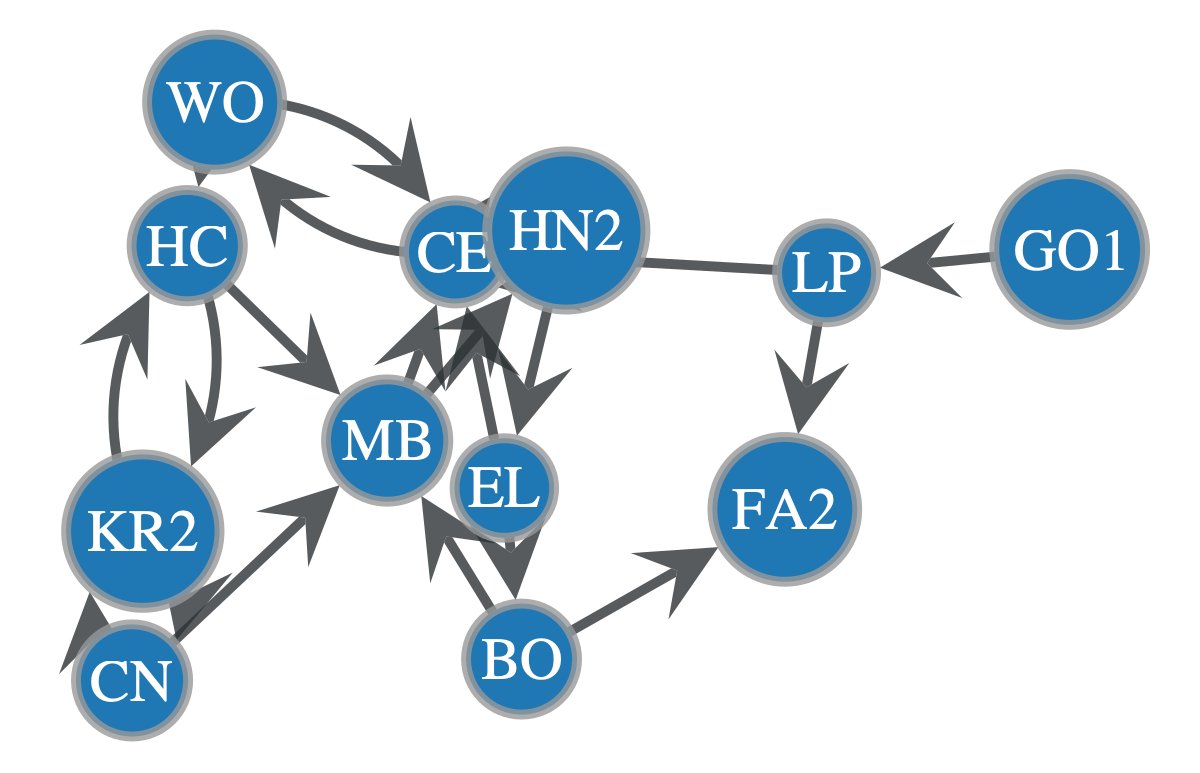

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16e6c26f0, at 0x303a08ce0>

In [61]:
filter_lay = onion2.view_layers(['grade_1'])
search_res = onion2.searcher.search(g=filter_lay, 
                                    direction='bi', 
                                    max_dist=20, 
                                    show_plot=False
                                    )
v_colors = onionnet.visualisation.color_nodes(g=search_res, prop_name='layer')['v_color']
search_res.vp['v_color'] = v_colors
graph_draw(
    search_res,
    vertex_text=search_res.vp['name_decoded'], 
    pos=pos_sfdp, 
    vertex_fill_color=search_res.vp['v_color']
    )

## Bipartite graph creation

Earlier on we experimented with filtering the interlayers using lambda and some other functions. In OnionNet there is actually a dedicated way to do this kind of analysis between two layers of the network. This ignores intra-layer connections and filters to only nodes involved in the inter-layer links between these two layers, effectively creating a bipartite network. To do this use the `create_bipartite_gv` function

In [62]:
layer_1 = 'grade_1'
layer_2 = 'grade_2'
bipartite_gv = onion2.create_bipartite_gv(layer1=layer_1, layer2=layer_2)
bipartite_gv

<GraphView object, directed, with 19 vertices and 10 edges, 10 internal vertex properties, 6 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x177e8d460, at 0x177e8cec0>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x177e8d460, at 0x177e8cef0>, False), at 0x177e8d460>

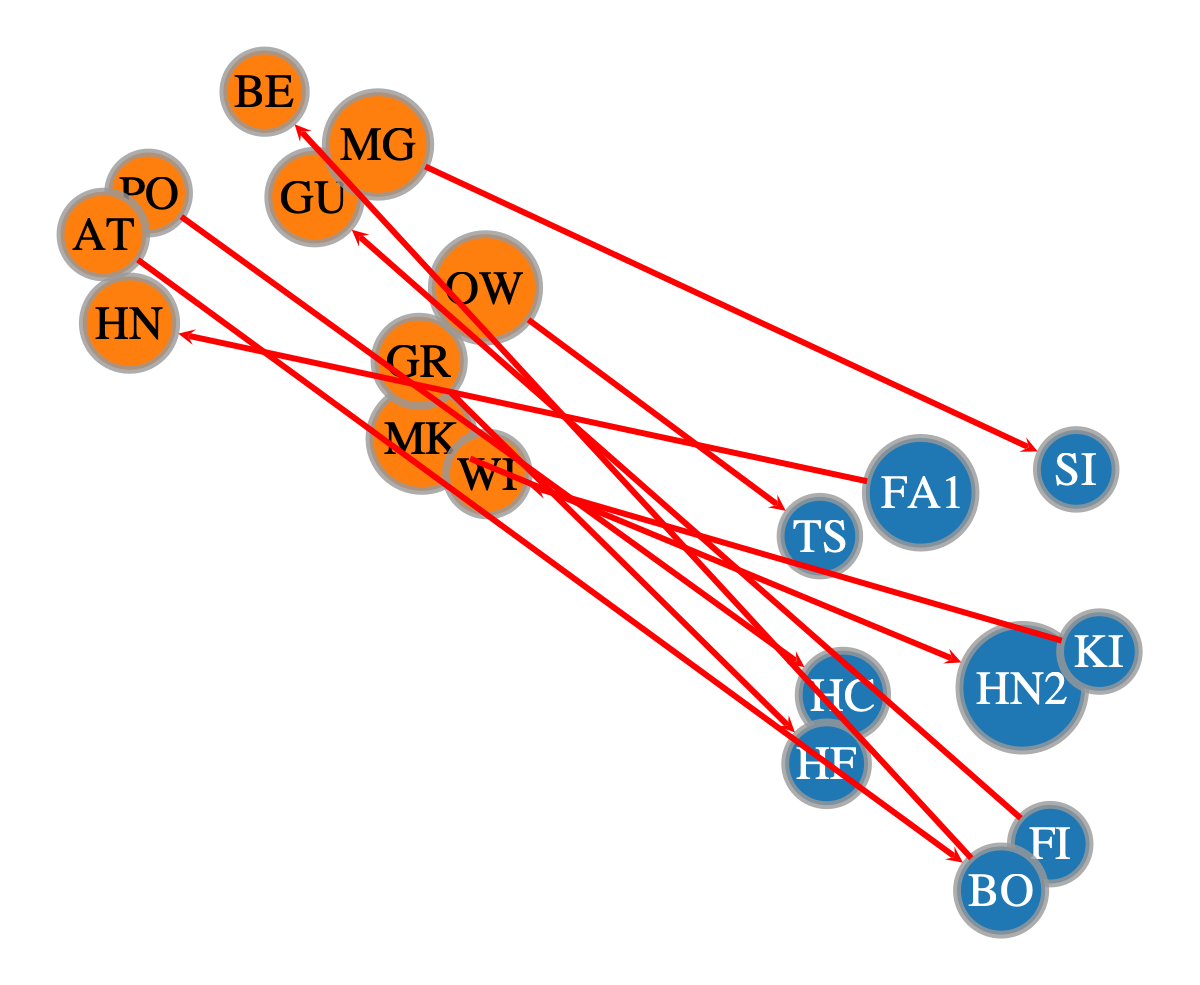

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x177e8d460, at 0x177e8dbe0>

In [63]:
graph_draw(bipartite_gv, 
           edge_pen_width=3.0,
           pos=pos_sfdp,
           vertex_text=search_res.vp['name_decoded'],
           vertex_fill_color=bipartite_gv.vp['v_color'], 
           edge_color=e_cols['e_color'],
           nodesfirst=True)

We could also view these with a more spread out layout 

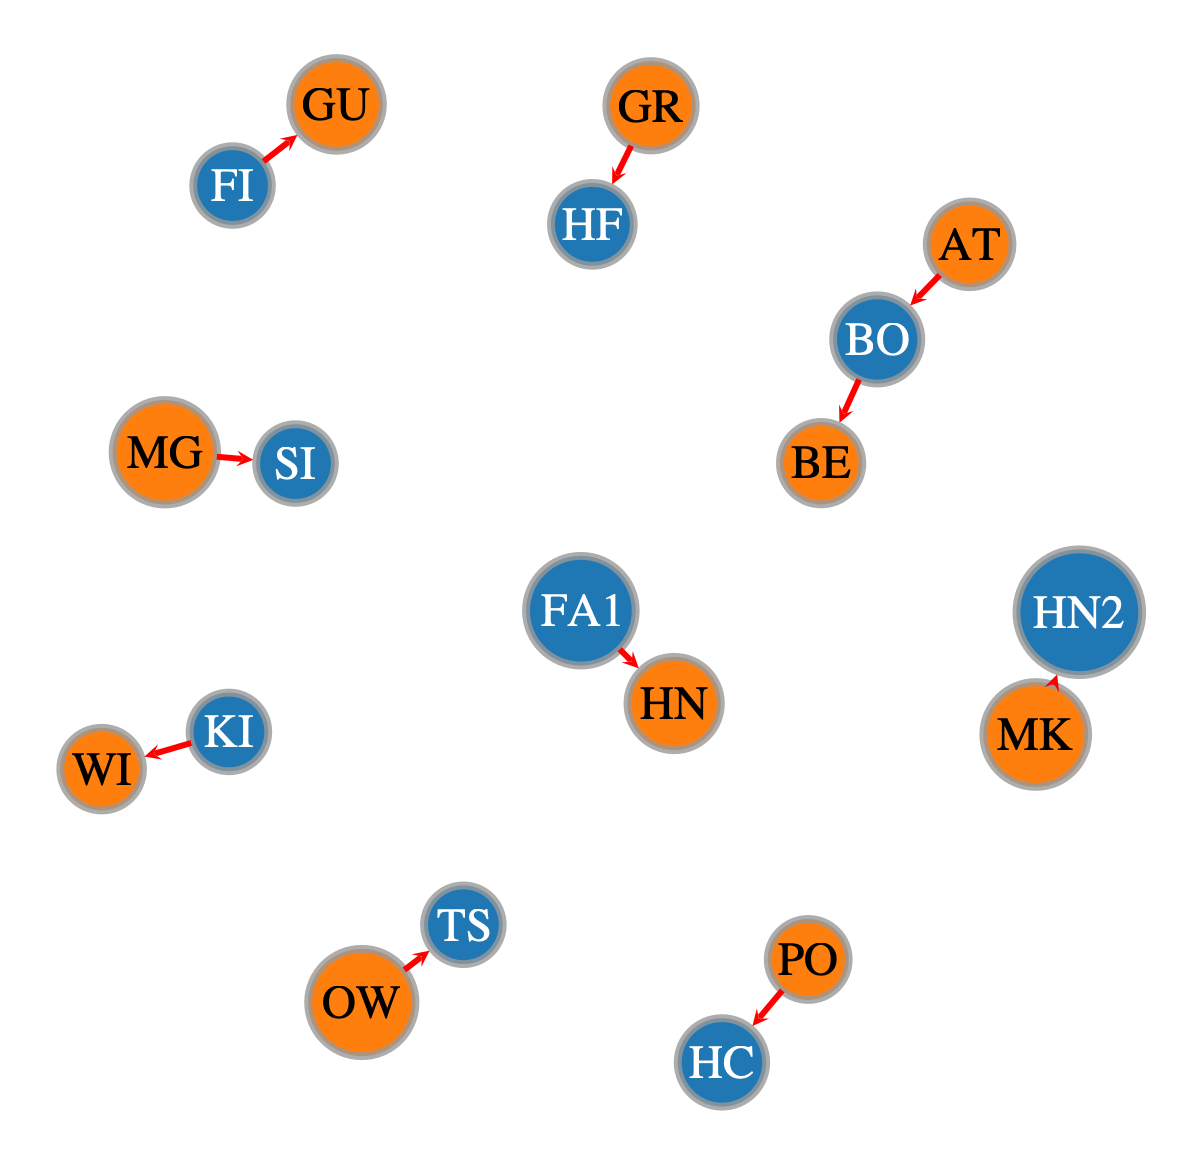

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x177e8d460, at 0x303a0b620>

In [64]:
graph_draw(bipartite_gv, 
           edge_pen_width=3.0,
           vertex_text=search_res.vp['name_decoded'],
           vertex_fill_color=bipartite_gv.vp['v_color'], 
           edge_color=e_cols['e_color'],
           nodesfirst=True)

Or we can even create a special bipartite layout to do this

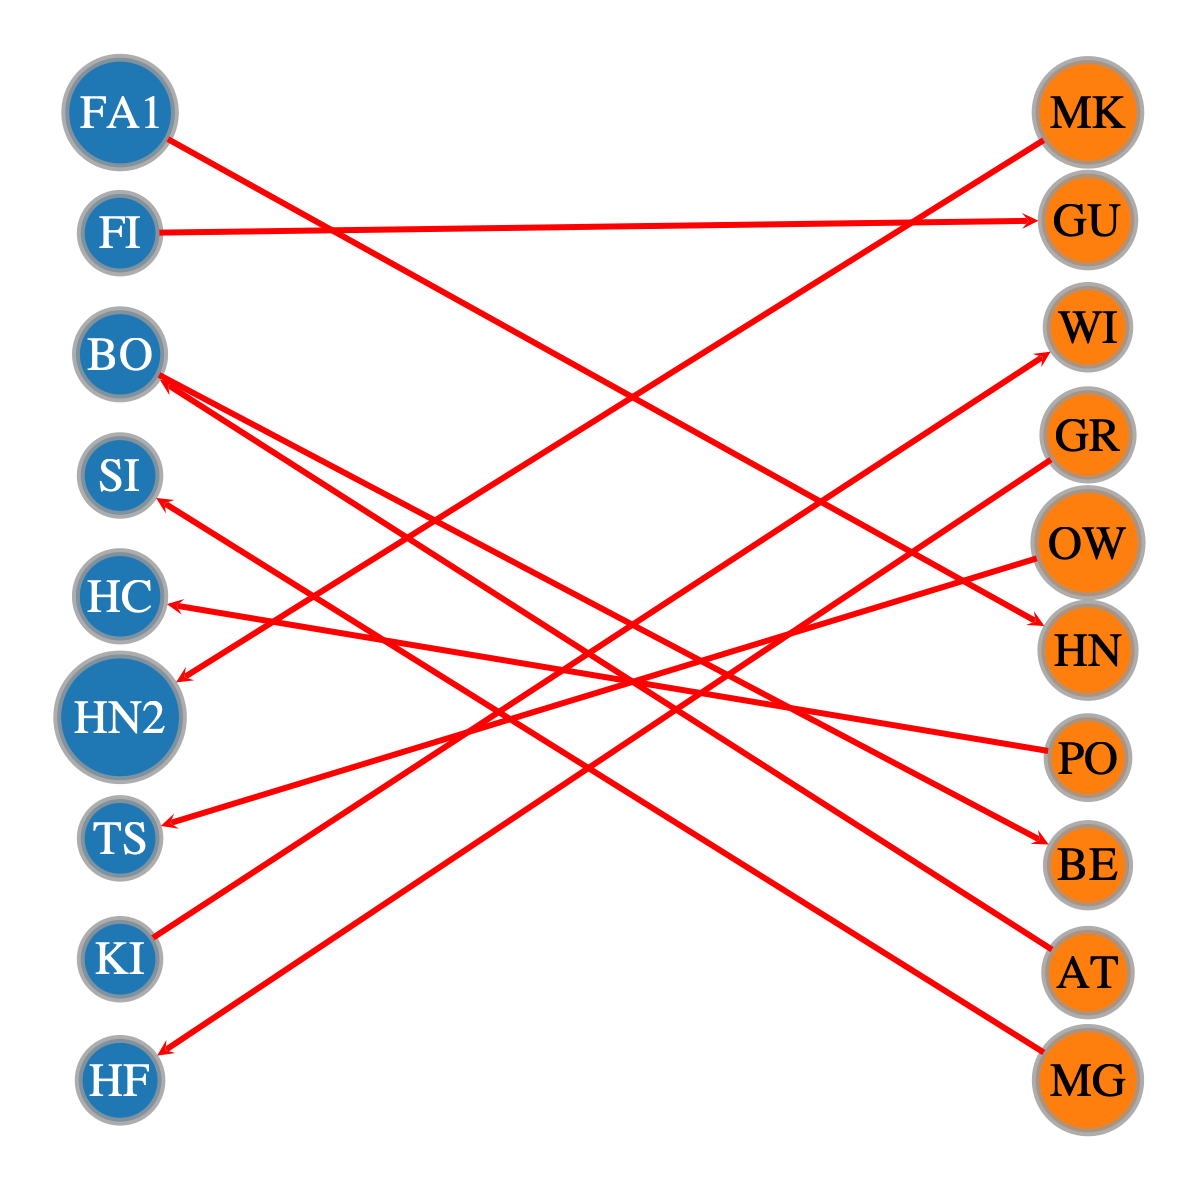

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x177e8d460, at 0x177ebc4a0>

In [65]:
pos_bipartite = onionnet.visualisation.layout_by_layer(bipartite_gv)

graph_draw(bipartite_gv, 
           edge_pen_width=3.0,
           pos=pos_bipartite,
           vertex_text=search_res.vp['name_decoded'],
           vertex_fill_color=bipartite_gv.vp['v_color'], 
           edge_color=e_cols['e_color'],
           nodesfirst=True)

We can also order this to improve the ability to discern patterns in the connections. This allows us to more easily see the double connection between BO.

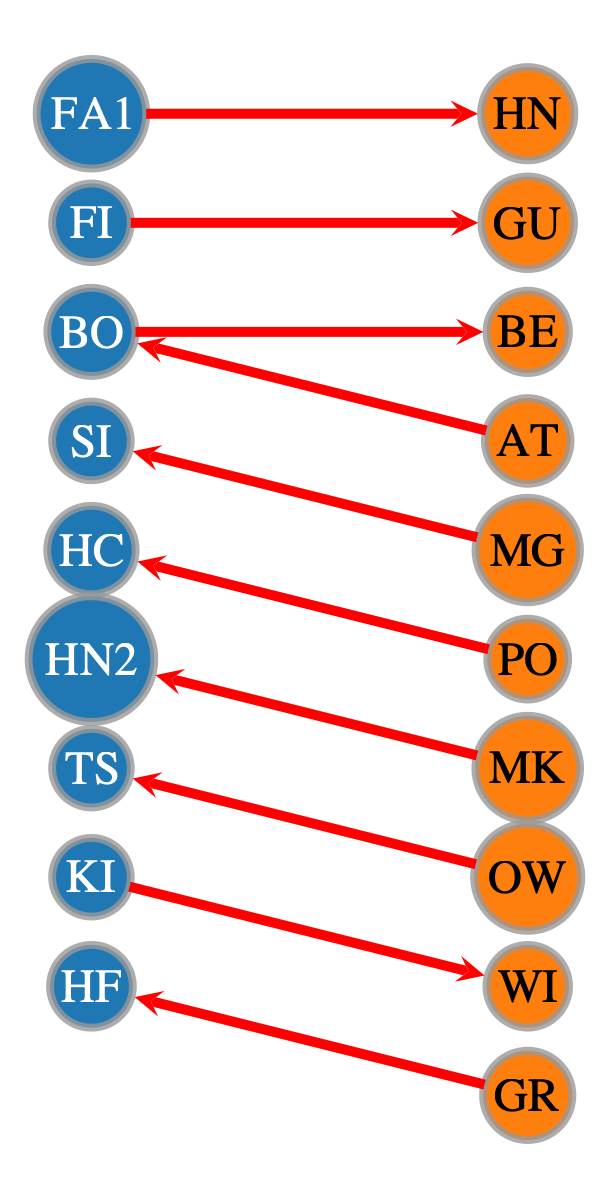

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x177e8d460, at 0x177e8c200>

In [66]:
pos_bipartite_ordered = onionnet.visualisation.bipartite_ordered_layout(bipartite_gv, left_val='grade_1', right_val='grade_2', 
                                                                        vertical_spacing=100, horizontal_spacing=400)

graph_draw(bipartite_gv, 
           edge_pen_width=5.0,
           pos=pos_bipartite_ordered,
           vertex_text=search_res.vp['name_decoded'],
           vertex_fill_color=bipartite_gv.vp['v_color'], 
           edge_color=e_cols['e_color'],
           nodesfirst=True)

## Exporting filtered graphs

What if we want to now export the data from our filtered network into a dataframe or list, etc.? OnionNet includes a function to do just that: `export_info()`. By default this will include all node properties. Note however that they will be in the encoded integer format unless we have already decoded certain properties, like we did for `name_decoded` earlier.

In [67]:
onionnet.exporter.export_info(search_res, mode='v')

,v_int,layer_hash,node_id_hash,node_id,name,_pos,layer,layer_decoded,node_id_decoded,name_decoded,v_color
0,0,0,0,0,0,0,0,grade_1,0,GO1,"[0.12156862745098039, 0.4666666666666667, 0.70..."
1,1,0,1,1,1,1,0,grade_1,1,LP,"[0.12156862745098039, 0.4666666666666667, 0.70..."
2,3,0,3,3,3,3,0,grade_1,3,WO,"[0.12156862745098039, 0.4666666666666667, 0.70..."
3,6,0,6,6,6,6,0,grade_1,6,CE,"[0.12156862745098039, 0.4666666666666667, 0.70..."
4,8,0,34,8,8,8,0,grade_1,8,FA2,"[0.12156862745098039, 0.4666666666666667, 0.70..."
5,10,0,9,10,10,10,0,grade_1,10,BO,"[0.12156862745098039, 0.4666666666666667, 0.70..."
6,17,0,16,17,17,17,0,grade_1,17,HC,"[0.12156862745098039, 0.4666666666666667, 0.70..."
7,20,0,19,20,20,20,0,grade_1,20,KR2,"[0.12156862745098039, 0.4666666666666667, 0.70..."
8,21,0,20,21,21,21,0,grade_1,21,MB,"[0.12156862745098039, 0.4666666666666667, 0.70..."
9,23,0,22,23,23,23,0,grade_1,23,HN2,"[0.12156862745098039, 0.4666666666666667, 0.70..."


We can also do the same for edges

In [68]:
onionnet.exporter.export_info(search_res, mode='e')

,e_id,source,target,source_id,target_id,source_layer,target_layer,interlayer,e_color
0,0,0,1,0,0,0,0,0,"[0.5, 0.5, 0.5, 1.0]"
1,1,1,8,1,1,0,0,0,"[0.5, 0.5, 0.5, 1.0]"
2,2,1,6,1,2,0,0,0,"[0.5, 0.5, 0.5, 1.0]"
3,5,3,6,3,2,0,0,0,"[0.5, 0.5, 0.5, 1.0]"
4,6,3,17,3,5,0,0,0,"[0.5, 0.5, 0.5, 1.0]"
5,10,6,3,6,3,0,0,0,"[0.5, 0.5, 0.5, 1.0]"
6,11,6,23,6,7,0,0,0,"[0.5, 0.5, 0.5, 1.0]"
7,16,10,8,9,1,0,0,0,"[0.5, 0.5, 0.5, 1.0]"
8,17,10,21,9,10,0,0,0,"[0.5, 0.5, 0.5, 1.0]"
9,32,17,20,16,15,0,0,0,"[0.5, 0.5, 0.5, 1.0]"


Note the differences between source and targets.

This isn't super informative to our human eyes so let's bulk decode all properties then export it.

In [69]:
onion2.decode_property_labels_bulk(df=df_nodes, encoded_prop_type='v',)

node_id prop left as is, no decoding needed (not an object type)
V property 'name_decoded' created successfully.
V property '_pos_decoded' created successfully.
V property 'layer_decoded' created successfully.


In [70]:
onion2.decode_property_labels_bulk(df=df_edges_with_friends, encoded_prop_type='e')

source_id prop left as is, no decoding needed (not an object type)
target_id prop left as is, no decoding needed (not an object type)
E property 'source_layer_decoded' created successfully.
E property 'target_layer_decoded' created successfully.
interlayer prop left as is, no decoding needed (not an object type)


Now that we've decoded the properties we need to rerun the search filtering

In [71]:
filter_lay = onion2.view_layers(['grade_1'])
search_res = onion2.searcher.search(g=filter_lay, 
                                    direction='bi', 
                                    max_dist=20, 
                                    show_plot=False
                                    )

Filtered graph contains 12 vertices and 21 edges.


In [72]:
onionnet.exporter.export_info(search_res, mode='v')

,v_int,layer_hash,node_id_hash,node_id,name,_pos,layer,layer_decoded,node_id_decoded,name_decoded,v_color,_pos_decoded
0,0,0,0,0,0,0,0,grade_1,0,GO1,"[0.12156862745098039, 0.4666666666666667, 0.70...","array([-2.98488506, 0.86791962])"
1,1,0,1,1,1,1,0,grade_1,1,LP,"[0.12156862745098039, 0.4666666666666667, 0.70...","array([-2.95675841, 1.34825587])"
2,3,0,3,3,3,3,0,grade_1,3,WO,"[0.12156862745098039, 0.4666666666666667, 0.70...","array([-3.34686456, 2.41781597])"
3,6,0,6,6,6,6,0,grade_1,6,CE,"[0.12156862745098039, 0.4666666666666667, 0.70...","array([-3.1286156 , 1.92922718])"
4,8,0,34,8,8,8,0,grade_1,8,FA2,"[0.12156862745098039, 0.4666666666666667, 0.70...","array([-2.36291912, 1.56251772])"
5,10,0,9,10,10,10,0,grade_1,10,BO,"[0.12156862745098039, 0.4666666666666667, 0.70...","array([-2.33046436, 1.82920065])"
6,17,0,16,17,17,17,0,grade_1,17,HC,"[0.12156862745098039, 0.4666666666666667, 0.70...","array([-2.8254759 , 2.72389501])"
7,20,0,19,20,20,20,0,grade_1,20,KR2,"[0.12156862745098039, 0.4666666666666667, 0.70...","array([-2.32950725, 2.56577117])"
8,21,0,20,21,21,21,0,grade_1,21,MB,"[0.12156862745098039, 0.4666666666666667, 0.70...","array([-2.56942449, 2.24026267])"
9,23,0,22,23,23,23,0,grade_1,23,HN2,"[0.12156862745098039, 0.4666666666666667, 0.70...","array([-2.9291481, 2.0509106])"


In [73]:
onionnet.exporter.export_info(search_res, mode='e')

,e_id,source,target,source_id,target_id,source_layer,target_layer,interlayer,e_color,source_layer_decoded,target_layer_decoded
0,0,0,1,0,0,0,0,0,"[0.5, 0.5, 0.5, 1.0]",grade_1,grade_1
1,1,1,8,1,1,0,0,0,"[0.5, 0.5, 0.5, 1.0]",grade_1,grade_1
2,2,1,6,1,2,0,0,0,"[0.5, 0.5, 0.5, 1.0]",grade_1,grade_1
3,5,3,6,3,2,0,0,0,"[0.5, 0.5, 0.5, 1.0]",grade_1,grade_1
4,6,3,17,3,5,0,0,0,"[0.5, 0.5, 0.5, 1.0]",grade_1,grade_1
5,10,6,3,6,3,0,0,0,"[0.5, 0.5, 0.5, 1.0]",grade_1,grade_1
6,11,6,23,6,7,0,0,0,"[0.5, 0.5, 0.5, 1.0]",grade_1,grade_1
7,16,10,8,9,1,0,0,0,"[0.5, 0.5, 0.5, 1.0]",grade_1,grade_1
8,17,10,21,9,10,0,0,0,"[0.5, 0.5, 0.5, 1.0]",grade_1,grade_1
9,32,17,20,16,15,0,0,0,"[0.5, 0.5, 0.5, 1.0]",grade_1,grade_1


Wallah, all the decoded vertex and edge properties have now been exported.